In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [28]:
!git clone https://github.com/harshita10sharma/market-sentiment-vs-trader-performance.git
sent = pd.read_csv('/content/market-sentiment-vs-trader-performance/data/fear_greed_index.csv')
trade = pd.read_csv('/content/market-sentiment-vs-trader-performance/data/historical_data.csv')


fatal: destination path 'market-sentiment-vs-trader-performance' already exists and is not an empty directory.


In [29]:
sent

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05
...,...,...,...,...
2639,1745818200,54,Neutral,2025-04-28
2640,1745904600,60,Greed,2025-04-29
2641,1745991000,56,Greed,2025-04-30
2642,1746077400,53,Neutral,2025-05-01


In [30]:
trade

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12


In [31]:
trade.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [32]:
trade.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [33]:
sent.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [34]:
trade['time'] = pd.to_datetime(trade['Timestamp'], unit='ms')
sent['date'] = pd.to_datetime(sent['date'])

In [35]:
trade['date'] = trade['time'].dt.date
sent['date'] = sent['date'].dt.date

In [36]:
sent['classification'].unique()

array(['Fear', 'Extreme Fear', 'Neutral', 'Greed', 'Extreme Greed'],
      dtype=object)

In [37]:
sent.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [38]:
trade.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [39]:
trade.duplicated().sum()

np.int64(0)

In [40]:
sent.duplicated().sum()

np.int64(0)

In [41]:
print("Unique values in each column of traders:")
for col in trade.columns:
    print(col, ":", trade[col].nunique())

Unique values in each column of traders:
Account : 32
Coin : 246
Execution Price : 60162
Size Tokens : 59304
Size USD : 118493
Side : 2
Timestamp IST : 27977
Start Position : 196923
Direction : 12
Closed PnL : 90720
Transaction Hash : 101184
Order ID : 50555
Crossed : 2
Fee : 138802
Trade ID : 2810
Timestamp : 7
time : 7
date : 7


In [42]:
print("Unique values in each column of sentiment:")
for col in sent.columns:
    print(col, ":", sent[col].nunique())

Unique values in each column of sentiment:
timestamp : 2644
value : 90
classification : 5
date : 2644


In [43]:
for col in trade.columns:
    print("Value counts for ")
    print(trade[col].value_counts())
    print("--------------------------------------------------")


Value counts for 
Account
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    40184
0xbaaaf6571ab7d571043ff1e313a9609a10637864    21192
0xa0feb3725a9335f49874d7cd8eaad6be45b27416    15605
0x8477e447846c758f5a675856001ea72298fd9cb5    14998
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    14733
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    13311
0x513b8629fe877bb581bf244e326a047b249c4ff1    12236
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4     9893
0x47add9a56df66b524d5e2c1993a43cde53b6ed85     8519
0x4f93fead39b70a1824f981a54d4e55b278e9f760     7584
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     7280
0xb899e522b5715391ae1d4f137653e7906c5e2115     4838
0x8170715b3b381dffb7062c0298972d4727a0a63b     4601
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4     4356
0x083384f897ee0f19899168e3b1bec365f52a9012     3818
0x271b280974205ca63b716753467d5a371de622ab     3809
0x39cef799f8b69da1995852eea189df24eb5cae3c     3589
0x2c229d22b100a7beb69122eed721cee9b24011dd     3239
0x92f17e8d81a944691c10e753af1b1baae1a2

In [44]:
for col in sent.columns:
    print("Value counts for ")
    print(sent[col].value_counts())
    print("--------------------------------------------------")


Value counts for 
timestamp
1746163800    1
1517463000    1
1517549400    1
1517635800    1
1744781400    1
             ..
1518154200    1
1518067800    1
1517981400    1
1517895000    1
1517808600    1
Name: count, Length: 2644, dtype: int64
--------------------------------------------------
Value counts for 
value
50    70
24    61
27    60
72    60
20    58
      ..
87     4
89     3
7      2
6      2
5      1
Name: count, Length: 90, dtype: int64
--------------------------------------------------
Value counts for 
classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64
--------------------------------------------------
Value counts for 
date
2025-05-02    1
2018-02-01    1
2018-02-02    1
2018-02-03    1
2025-04-16    1
             ..
2018-02-09    1
2018-02-08    1
2018-02-07    1
2018-02-06    1
2018-02-05    1
Name: count, Length: 2644, dtype: int64
---------------------------------------

In [45]:
sent['Classification'] = np.where(
    sent['classification'].str.contains('Fear'), 'Fear',
    np.where(sent['classification'].str.contains('Greed'), 'Greed', 'Neutral')
)

sent = sent[sent['Classification'] != 'Neutral']

In [46]:
df = trade.merge(sent[['date','Classification']], on='date', how='left')
df = df.dropna(subset=['Classification'])

In [47]:
df

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,time,date,Classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.000000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.000000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.000000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.000000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27 03:33:20,2024-10-27,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.000000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27 03:33:20,2024-10-27,Greed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210763,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,SOL,133.6000,4.13,551.77,BUY,18-04-2025 20:03,-1797.880000,Close Short,-82.883731,0xbbde0f181b617f8d2e2a0421c9a82a02077000c2d6ba...,87333347541,False,0.055176,6.900000e+14,1.740000e+12,2025-02-19 21:20:00,2025-02-19,Fear
210764,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,SOL,133.6000,7.50,1002.00,BUY,18-04-2025 20:03,-1793.750000,Close Short,-150.515250,0x6bd337120e6f682326d30421c9a82a02077100566072...,87333347541,False,0.100200,6.610000e+13,1.740000e+12,2025-02-19 21:20:00,2025-02-19,Fear
210765,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,SOL,133.6000,3.93,525.05,BUY,18-04-2025 20:03,-1786.250000,Close Short,-78.869991,0xdbff44ed44a78acf124c0421c9a82a0207720000b450...,87333347541,False,0.052504,1.010000e+15,1.740000e+12,2025-02-19 21:20:00,2025-02-19,Fear
210766,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,SOL,133.6000,4.34,579.82,BUY,18-04-2025 20:03,-1782.320000,Close Short,-87.098158,0xd8f4fcfddd57c09658a90421c9a82a0207780007b85e...,87333347541,False,0.057982,2.700000e+13,1.740000e+12,2025-02-19 21:20:00,2025-02-19,Fear


In [48]:
df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'time', 'date', 'Classification'],
      dtype='object')

In [49]:
df['win'] = (df['Closed PnL'] > 0).astype(int)
df['is_long'] = (df['Side'] == 'BUY').astype(int)

df['size_cat'] = pd.cut(df['Size USD'], bins=4, labels=[0,1,2,3])
df['sentiment'] = df['Classification'].map({'Fear':0,'Greed':1})

In [50]:
# trades per user
df['trades_per_user'] = df.groupby('Account')['Account'].transform('count')

# avg pnl per user
df['avg_pnl_user'] = df.groupby('Account')['Closed PnL'].transform('mean')

# rolling risk proxy
df['pnl_std_user'] = df.groupby('Account')['Closed PnL'].transform('std')

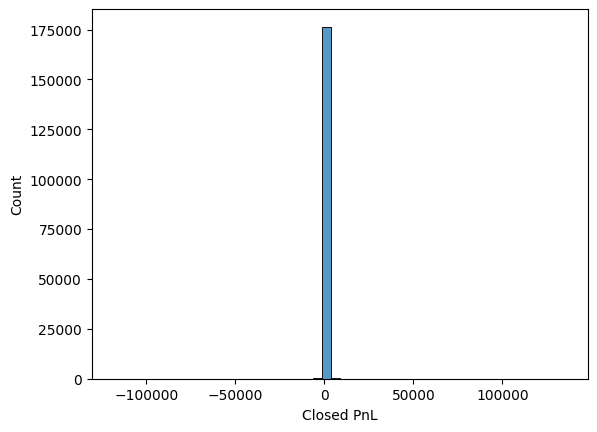

In [51]:
sns.histplot(df['Closed PnL'], bins=50)
plt.show()

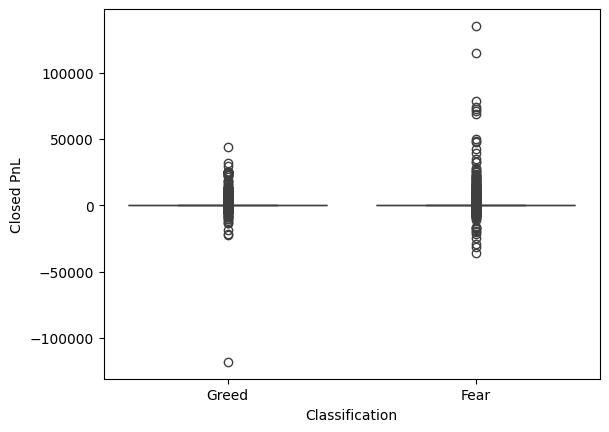

In [52]:
sns.boxplot(x='Classification', y='Closed PnL', data=df)
plt.show()

 1. Performance: Fear vs Greed

In [53]:
df.groupby('Classification')['Closed PnL'].agg(['mean','median','std'])

,mean,median,std
Classification,,,
Fear,50.047622,0.0,909.121796
Greed,77.838247,0.0,1059.262203


In [54]:
df.groupby('Classification')['win'].mean()

,win
Classification,
Fear,0.415146
Greed,0.453492


2. Behavior: Risk (Size)

In [55]:
df.groupby('Classification')['Size USD'].mean()
df.groupby('Classification')['is_long'].mean()
df.groupby('Classification').size()

,0
Classification,
Fear,133871
Greed,43251


Risk (size)

In [56]:
df.groupby('size_cat')['Closed PnL'].mean()
df.groupby('size_cat')['win'].mean()

,win
size_cat,
0,0.424490
1,0.642857
2,0.500000
3,0.500000


 Trader types

In [57]:
# frequent vs infrequent
df['trades_per_user'].describe()

# consistent vs inconsistent
df['pnl_std_user'].describe()

,pnl_std_user
count,177122.000000
mean,546.962289
std,770.053165
min,72.662299
25%,119.887028
50%,276.743292
75%,567.789417
max,4692.452329


# Size category vs performance

In [58]:
df.groupby('size_cat')['Closed PnL'].mean()

,Closed PnL
size_cat,
0,55.765358
1,11434.887940
2,7028.811801
3,1073.557605


In [59]:
df.groupby('size_cat')['win'].mean()

,win
size_cat,
0,0.424490
1,0.642857
2,0.500000
3,0.500000


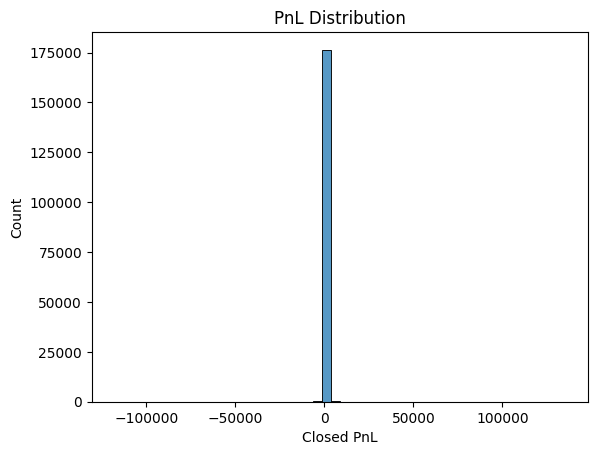

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Closed PnL'], bins=50)
plt.title("PnL Distribution")
plt.show()

Fear vs Greed Boxplot

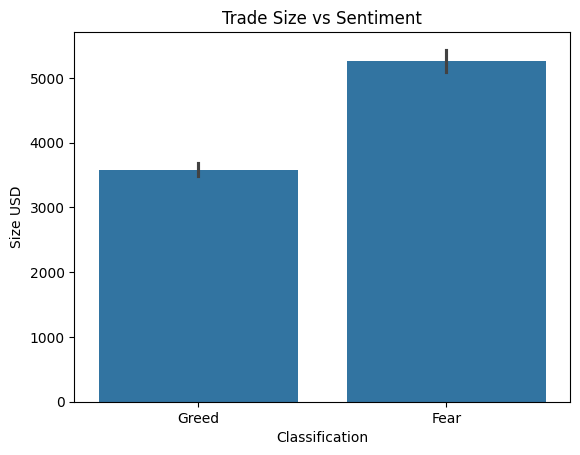

In [61]:
sns.barplot(x='Classification', y='Size USD', data=df)
plt.title("Trade Size vs Sentiment")
plt.show()

Trade size behavior

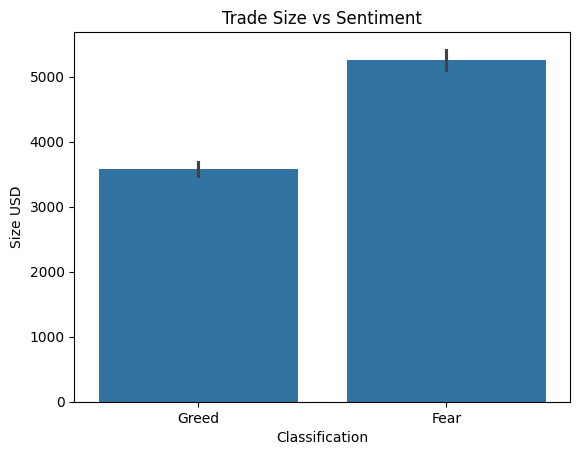

In [62]:
sns.barplot(x='Classification', y='Size USD', data=df)
plt.title("Trade Size vs Sentiment")
plt.show()

Win Rate Pie Chart

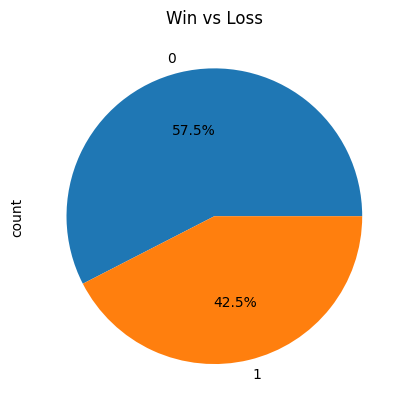

In [63]:
df['win'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Win vs Loss")
plt.show()

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 177122 entries, 0 to 210767
Data columns (total 26 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           177122 non-null  object        
 1   Coin              177122 non-null  object        
 2   Execution Price   177122 non-null  float64       
 3   Size Tokens       177122 non-null  float64       
 4   Size USD          177122 non-null  float64       
 5   Side              177122 non-null  object        
 6   Timestamp IST     177122 non-null  object        
 7   Start Position    177122 non-null  float64       
 8   Direction         177122 non-null  object        
 9   Closed PnL        177122 non-null  float64       
 10  Transaction Hash  177122 non-null  object        
 11  Order ID          177122 non-null  int64         
 12  Crossed           177122 non-null  bool          
 13  Fee               177122 non-null  float64       
 14  Trade ID 

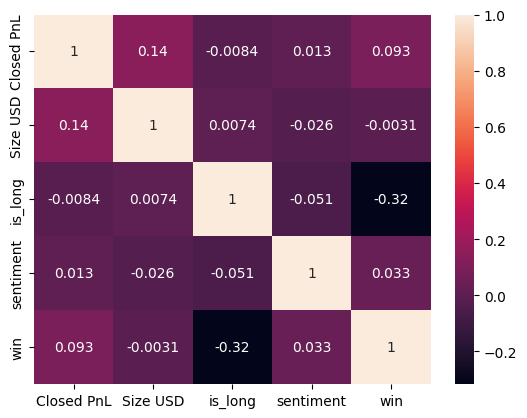

In [65]:
sns.heatmap(df[['Closed PnL','Size USD','is_long','sentiment','win']].corr(), annot=True)
plt.show()